# XGBoost Regression and Interpretability Analysis

## 1. Data Preparation, Modeling, and Evaluation


### 1.0 Global Configuration
Configure the main program parameters, including data and model sources.
This cell must be run.

In [12]:
# ==================== Global Configuration (edit here first) ====================
from pathlib import Path
import re
import pandas as pd

# Automatically detect the project root directory
PROJECT_ROOT = Path.cwd()

# Data file path, target column, and columns to exclude
DATA_PATH = PROJECT_ROOT / "Example" / "ALL_data_analysis" / "ALL_exp._results.csv"
TARGET_COLUMN = "EGT efficiency cost (mg /CNY)"
ANALYSIS_ROUND = ["Round 1","Round 2","Round 3","Round 4"]
DROP_COLUMNS = ["Round","EGT titer (mg/L)","Medium material cost (CNY/L)" ]


# Set and create output directories; new results overwrite files with the same name.
OUTPUT_ROOT = PROJECT_ROOT / "Example" / "ALL_data_analysis" / "SHAP_outputs"
MODELING_OUTPUT_DIR = OUTPUT_ROOT / "01_modeling"
SHAP_MAIN_OUTPUT_DIR = OUTPUT_ROOT / "02_shap_main"
SHAP_INTERACTION_OUTPUT_DIR = OUTPUT_ROOT / "03_shap_interaction"


for output_dir in (
    MODELING_OUTPUT_DIR,
    SHAP_MAIN_OUTPUT_DIR,
    SHAP_INTERACTION_OUTPUT_DIR,
):
    output_dir.mkdir(parents=True, exist_ok=True)

# Random seed configuration
RANDOM_SEED = 42


# Configure trained model loading; by default, the model is stored in the output directory
LOAD_EXISTING_MODEL = False  # True loads a trained model; False retrains the model
MODEL_PATH = OUTPUT_ROOT / "01_modeling" / "best_xgb_titer.joblib" 


# -------Data Loading and Chemical Formula Formatting---------
# Load the training dataset
data = pd.read_csv(DATA_PATH)
data = data[data["Round"].isin(ANALYSIS_ROUND)]
data = data.drop(columns=DROP_COLUMNS)

# X contains features; y contains target labels
X = data.drop(columns=[TARGET_COLUMN])
y = data[TARGET_COLUMN]
rawcolumns = X.columns.values

# Create chemical formula label mappings for input features for plotting
feature_label_map = {
    '(NH4)2SO4 (g/L)': r'$\mathrm{(NH_4)_2SO_4}$',
    'Triton X-100 (g/L)': r'$\mathrm{Triton\ X\text{-}100}$', 
    'Glycine (g/L)': r'$\mathrm{Glycine}$',
    'CSL-P (g/L)':r'$\mathrm{CSL\text{-}P}$',
    'NaCl (g/L)': r'$\mathrm{NaCl}$',
    'K2HPO4 (g/L)': r'$\mathrm{K_2HPO_4}$',
    'Tryptone (g/L)': r'$\mathrm{Tryptone}$',
    'YE (g/L)': r'$\mathrm{YE}$',
    'Methionine (g/L)':r'$\mathrm{Methionine}$',
    'Cysteine (g/L)':r'$\mathrm{Cysteine}$',
    'NH4OAc (g/L)': r'$\mathrm{NH_4OAc}$',
    'Glycerol (g/L)': r'$\mathrm{Glycerol}$',
    'Na2S2O3 (g/L)':r'$\mathrm{Na_2S_2O_3}$',
    'ZnSO4·7H2O (g/L)': r'$\mathrm{ZnSO_4}\!\cdot\!\mathrm{7H_2O}$',
    'MgSO4·7H2O (g/L)': r'$\mathrm{MgSO_4}\!\cdot\!\mathrm{7H_2O}$',
    'FAC (g/L)': r'$\mathrm{FAC}$'
    }


columns = [
    feature_label_map.get(name, name)
    for name in rawcolumns
]

def safe_filename(value):
    """Convert a feature name to text suitable for a Windows filename."""
    return re.sub(r'[<>:"/\|?*]+', "_", str(value)).strip().replace(" ", "_")


print(f"Project directory: {PROJECT_ROOT}")
print(f"Data file: {DATA_PATH}")
print(f"Output directory: {OUTPUT_ROOT}")


Project directory: c:\Users\Liaoyt\Desktop\Ai_medium\github
Data file: c:\Users\Liaoyt\Desktop\Ai_medium\github\Example\ALL_data_analysis\ALL_exp._results.csv
Output directory: c:\Users\Liaoyt\Desktop\Ai_medium\github\Example\ALL_data_analysis\SHAP_outputs


### 1.1 Data Loading, Model Tuning, and Feature Importance

Load the data, split it into training and test sets, and use 10-fold cross-validation and grid search to determine the optimal hyperparameters for the XGBoost regressor. Then calculate test MSE and export the best parameters, feature importance table, and feature importance plot.

Tuning complete; best model saved to: c:\Users\Liaoyt\Desktop\Ai_medium\github\Example\ALL_data_analysis\SHAP_outputs\01_modeling\best_xgb_titer.joblib
MSE: 1.0724022971299445
sort_importance_and_feature: [(np.float32(0.42369568), 'NH4OAc (g/L)'), (np.float32(0.15819147), '(NH4)2SO4 (g/L)'), (np.float32(0.08181272), 'Glycine (g/L)'), (np.float32(0.06919179), 'CSL-P (g/L)'), (np.float32(0.032878377), 'Glycerol (g/L)'), (np.float32(0.03154914), 'Cysteine (g/L)'), (np.float32(0.03110936), 'Tryptone (g/L)'), (np.float32(0.030397044), 'Triton X-100 (g/L)'), (np.float32(0.02980369), 'YE (g/L)'), (np.float32(0.024835294), 'Methionine (g/L)'), (np.float32(0.023997985), 'ZnSO4·7H2O (g/L)'), (np.float32(0.018057095), 'MgSO4·7H2O (g/L)'), (np.float32(0.013381043), 'NaCl (g/L)'), (np.float32(0.011566852), 'FAC (g/L)'), (np.float32(0.011456651), 'Na2S2O3 (g/L)'), (np.float32(0.008075783), 'K2HPO4 (g/L)')]


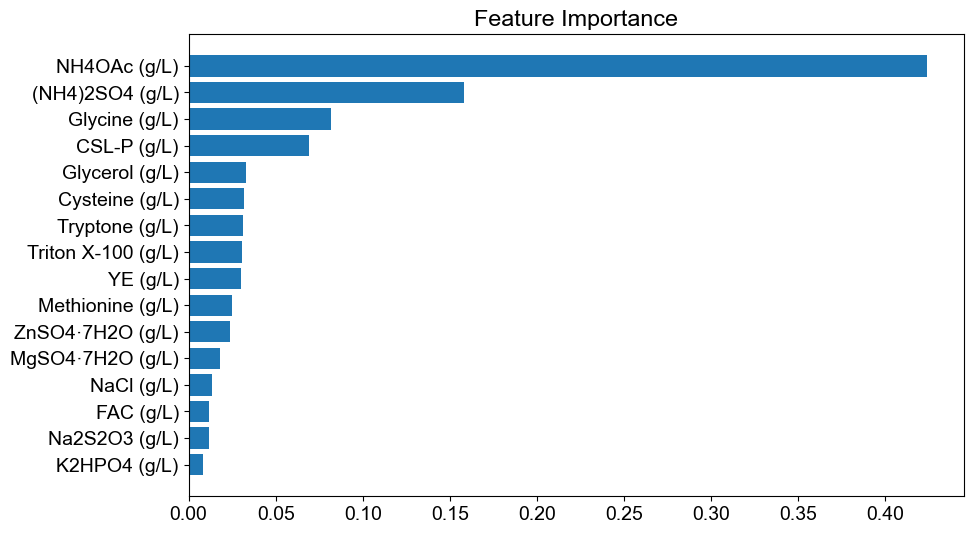

In [13]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from xgboost import plot_importance
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
import seaborn as sns
from scipy.interpolate import splev, splrep


# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
)

# Randomized hyperparameter search
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_SEED,
)
param_grid = {
    "learning_rate": [0.01, 0.03, 0.1, 0.3],
    "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
    "subsample": [0.6, 0.8, 0.9, 1.0],
    "max_depth": [2, 3, 4, 6 , 8],
    "n_estimators": [10, 20,  40, 60, 80, 100, 300, 500],
    "reg_lambda": [1, 1.5, 2],
    "gamma": [0, 0.1, 0.4, 0.6],
    "min_child_weight": [1, 2, 4]
    }   

grid_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    n_iter=200,     # Run 200 random search iterations
    random_state=RANDOM_SEED,
)


if LOAD_EXISTING_MODEL and MODEL_PATH.exists():

    best_model = joblib.load(MODEL_PATH)
    model_params = best_model.get_params()
    print(f'Loaded existing model: {MODEL_PATH}')
else:
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    joblib.dump(best_model, MODEL_PATH)
    print(f'Tuning complete; best model saved to: {MODEL_PATH}')



# Test set predictions and MSE
y_pred = best_model.predict(X_test)
mse = np.mean((y_pred - y_test) ** 2)
print('MSE:', mse)


# Feature Importance
importance = best_model.feature_importances_
sort_importance_and_feature = list(sorted(zip(importance, X.columns), reverse=True))
print('sort_importance_and_feature:', sort_importance_and_feature)
plt.figure(figsize=(10, 6))
plt.barh([x[1] for x in sort_importance_and_feature], [x[0] for x in sort_importance_and_feature])
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.savefig(MODELING_OUTPUT_DIR / 'feature_importance.png')
plt.show()

pd.DataFrame(
    sort_importance_and_feature,
    columns=['importance', 'feature'],
).to_csv(MODELING_OUTPUT_DIR / 'importance.csv', index=False)


### 1.2 Model Performance Evaluation

Calculate R², MSE, RMSE, MAE, and MAPE on the training and test sets to compare model fit and generalization performance.

In [14]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Calculate training set evaluation metrics
r2_score_train = best_model.score(X_train, y_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)  # Calculate RMSE
mae_train = mean_absolute_error(y_train, y_pred_train)
mape_train = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100

# Calculate test set evaluation metrics
r2_score_test = best_model.score(X_test, y_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)  # Calculate RMSE
mae_test = mean_absolute_error(y_test, y_pred_test)
mape_test = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

# Print all evaluation metrics
print("Training set evaluation metrics:")
print("R2:", r2_score_train)
print("MSE:", mse_train)
print("RMSE:", rmse_train)
print("MAE:", mae_train)
print("MAPE:", mape_train, "%")

print("\nTest set evaluation metrics:")
print("R2:", r2_score_test)
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("MAE:", mae_test)
print("MAPE:", mape_test, "%")

metrics_df = pd.DataFrame({
    'dataset': ['train', 'test'],
    'R2': [r2_score_train, r2_score_test],
    'MSE': [mse_train, mse_test],
    'RMSE': [rmse_train, rmse_test],
    'MAE': [mae_train, mae_test],
    'MAPE_percent': [mape_train, mape_test],
})
metrics_df.to_csv(MODELING_OUTPUT_DIR / 'model_metrics.csv', index=False)


Training set evaluation metrics:
R2: 0.9738019053888571
MSE: 0.1365208033772364
RMSE: 0.36948721679814095
MAE: 0.24108631974604125
MAPE: inf %

Test set evaluation metrics:
R2: 0.8236124553514996
MSE: 1.0724022971299445
RMSE: 1.035568586395872
MAE: 0.7940723434804267
MAPE: inf %


### 1.3 Feature Correlation Analysis

Calculate the correlation matrix for all variables and plot its upper triangle as a heatmap to examine linear correlations among features and between features and the target.

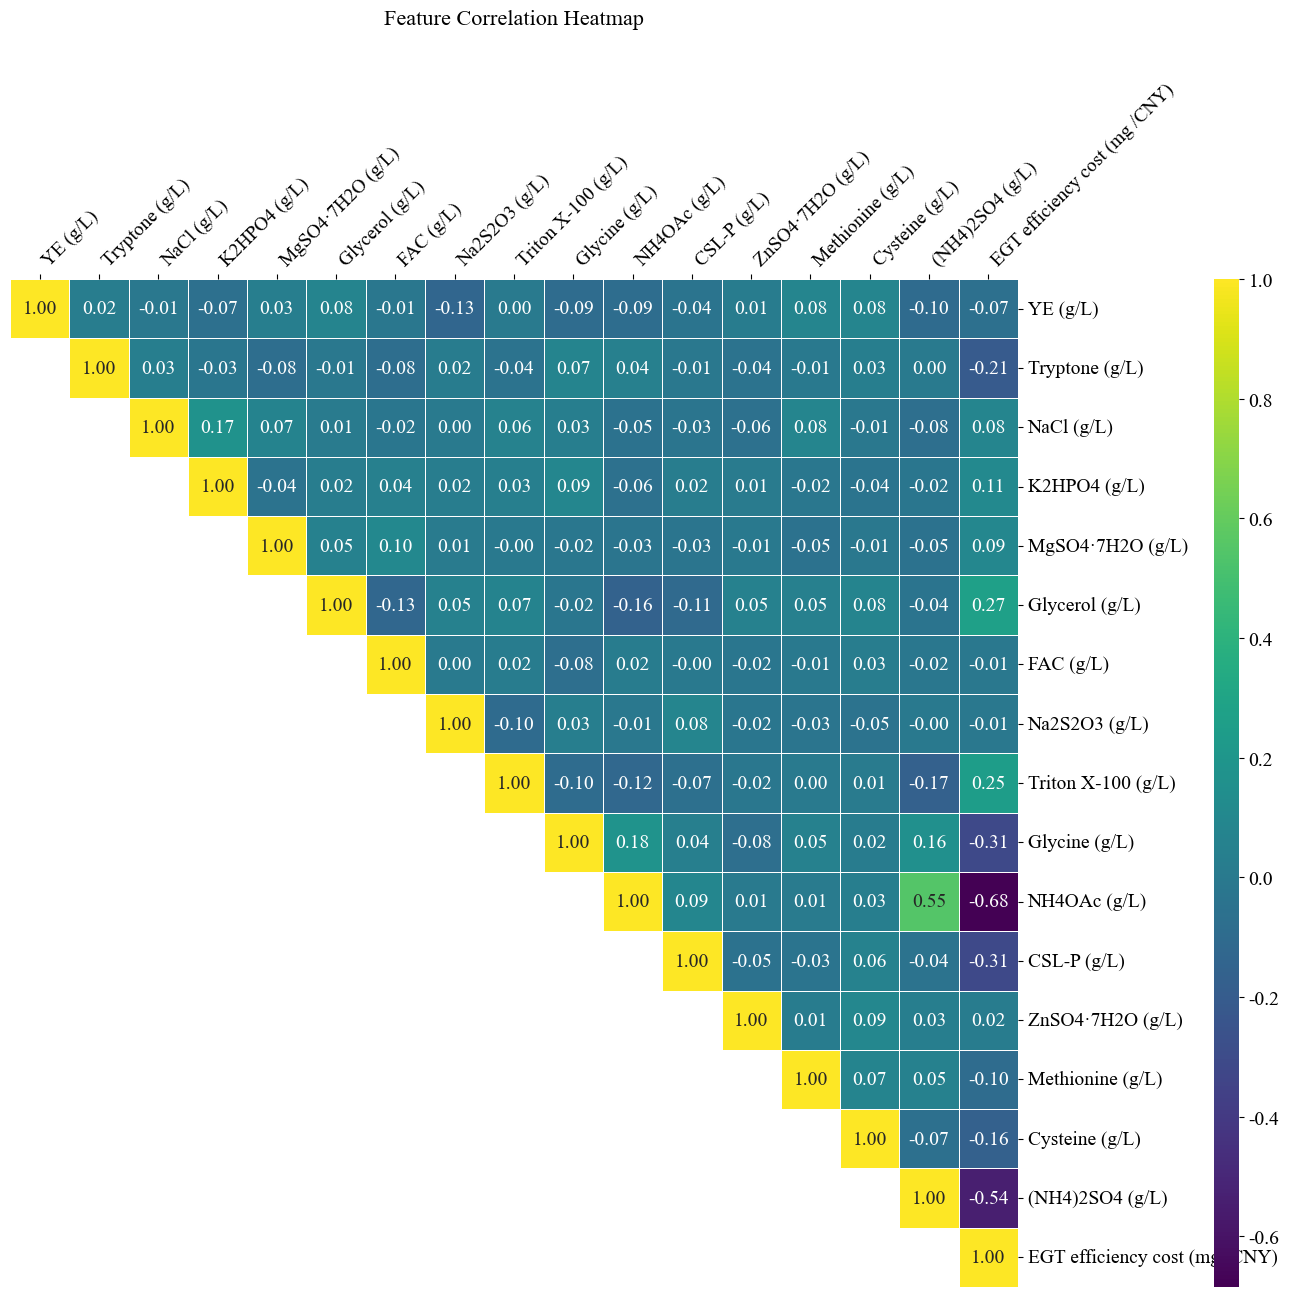

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Set global fonts ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['font.family'] = ['Times New Roman', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 14
# --------------------------
corr_matrix=data.corr()

# Increase figure width to leave more room for the colorbar and labels on the right
plt.figure(figsize=(16, 12))

# --- Define a custom colormap ---
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = plt.cm.viridis
# ----------------------------------------

# --- Create a mask to show the upper triangle (hide the lower triangle) ---
mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)  # k=0masks the diagonal; k=-1 keeps the diagonal visible

# --- Plot the upper-triangular heatmap ---
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=custom_cmap,
    fmt='.2f',
    annot_kws={"size": 14},
    mask=mask,  # Mask the lower triangle to show only the upper triangle
    # Adjust the colorbar position and spacing
    cbar_kws={
        "shrink": 1,        # Scale the colorbar height
        "location": "right",  # Place the colorbar on the right
        "pad": 0,          # Gap between the colorbar and heatmap (increase to move the colorbar right)
        "aspect": 40,         # Colorbar aspect ratio (larger values make it more slender)
        "anchor": (1, 0)  # Colorbar anchor for further rightward positioning
    },
    square=True,
    linewidths=0.5,
    linecolor='white',
    # Add padding inside the heatmap to keep content away from the edges
    yticklabels=True,
    xticklabels=True
)

# --- Adjust label positions and prevent overlap ---
# 1. Move X-axis tick labels to the top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
# 2. Move Y-axis tick labels to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

# --- Adjust Y-axis labels on the right ---
y_ticks = ax.get_yticklabels()
ax.set_yticklabels(
    y_ticks,
    rotation=0,
    ha='left',         # Align left, away from the heatmap
    va='center',       # Center vertically
    fontsize=14,
    # position=(1, 0) # Horizontal offset (1.03 shifts 3% to the right)
)

# --- Adjust X-axis labels at the top ---
x_ticks = ax.get_xticklabels()
ax.set_xticklabels(
    x_ticks,
    rotation=45,
    ha='left',
    va='bottom',
    fontsize=14
)

# --- Adjust the overall layout to reserve space on the right ---
plt.subplots_adjust(
    left=0.08,   # Left margin
    right=1,  # Right margin (decrease to reserve more space on the right)
    top=0.92,    # Top margin
    bottom=0.08  # Bottom margin
)

# --- Title and final adjustments ---
plt.title('Feature Correlation Heatmap', fontsize=16, pad=40)
# # Force layout adjustment to avoid clipping
# plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])

# Save the figure at high resolution
plt.savefig(
    MODELING_OUTPUT_DIR / 'feature_correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'  # White background
)
plt.show()

### 1.4 Observed vs. Predicted Values

Define a regression visualization function to show observed versus predicted values for the training and test sets on shared axes, with an ideal prediction line and R² and RMSE metrics to assess model performance.

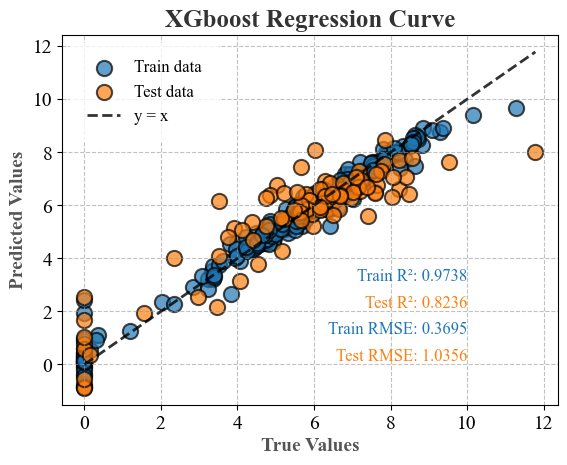

In [16]:



def plot_regression_curve(model, X_train, X_test, y_train, y_test, model_name):
    # Make predictions on training and testing data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate R², RMSE, and MAE
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Plot regression curve (with circles for data points)
    plt.scatter(y_train, y_train_pred, label="Train data", alpha=0.7, s=120, facecolors='#1f77b4', edgecolors='black', linewidth=1.5, marker='o')  # Train data
    plt.scatter(y_test, y_test_pred, label="Test data", alpha=0.7, s=120, facecolors='#ff7f0e', edgecolors='black', linewidth=1.5, marker='o')   # Test data

    # Plot ideal y=x line
    plt.plot([min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())],
            [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())],
            'k--', label="y = x", alpha=0.8, linewidth=2)

    # Set title and labels
    plt.title(f"{model_name} Regression Curve", fontsize=18, fontweight='bold', color='#333333')
    plt.xlabel("True Values", fontsize=14, fontweight='bold', color='#555555')
    plt.ylabel("Predicted Values", fontsize=14, fontweight='bold', color='#555555') 

    # Display R², RMSE in the bottom right corner
    plt.text(10, 3, f"Train R²: {r2_train:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#1f77b4')
    plt.text(10, 2, f"Test R²: {r2_test:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#ff7f0e')
    plt.text(10, 1, f"Train RMSE: {rmse_train:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#1f77b4')
    plt.text(10, 0, f"Test RMSE: {rmse_test:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#ff7f0e')

    # Beautify the plot
    plt.legend(loc="upper left", fontsize=12, fancybox=True, framealpha=0.8, facecolor='white', edgecolor='white', borderpad=1)
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.6, color='#999999')

    plt.savefig(MODELING_OUTPUT_DIR / f'{safe_filename(model_name)}_regression_curve.png', bbox_inches='tight')
    plt.show()

plot_regression_curve(best_model, X_train, X_test, y_train, y_test, 'XGboost')


### 1.5 Learning Curves

Plot learning curves to examine how training sample size affects training and cross-validation performance and help identify underfitting or overfitting.

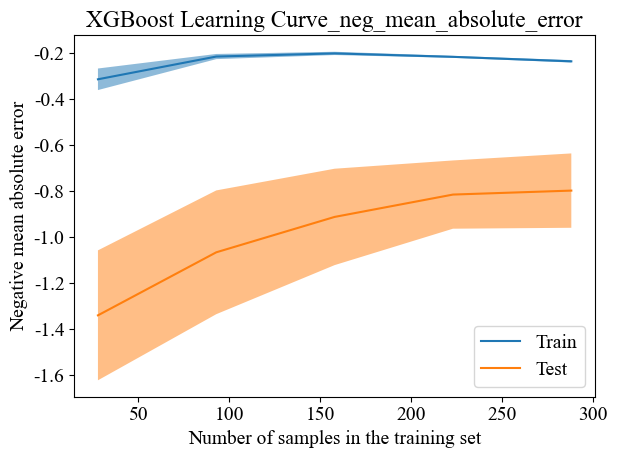

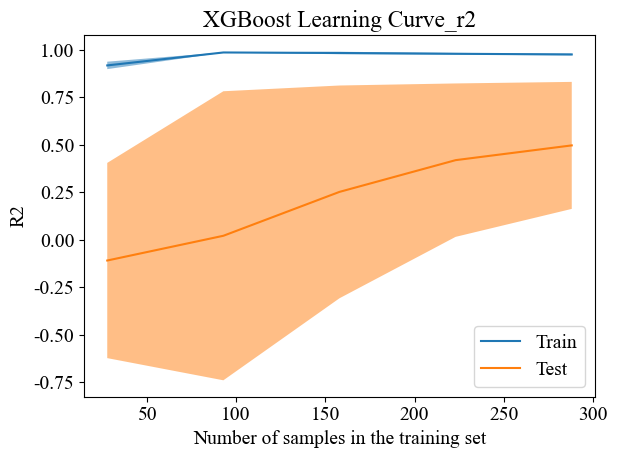

In [17]:
# import scikitplot as skplt

# skplt.estimators.plot_learning_curve(model, X, y)
# plt.show()

from sklearn.model_selection import LearningCurveDisplay
import numpy as np
import matplotlib.pyplot as plt



def plot_learning_curve(estimator, X, y, scoring="neg_mean_absolute_error"):
    """
    Plot the learning curve for a given estimator.
    """
    LearningCurveDisplay.from_estimator(
        estimator,
        X,
        y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=5,
        scoring=scoring,
        n_jobs=-1,
    )

    plt.title("XGBoost Learning Curve_{scoring}".format(scoring=scoring))
    plt.tight_layout()
    plt.savefig(
        MODELING_OUTPUT_DIR / "learning_curve_{scoring}.png".format(scoring=scoring),
        bbox_inches="tight",
    )
    plt.show()

plot_learning_curve(best_model, X, y, scoring="neg_mean_absolute_error")
plot_learning_curve(best_model, X, y, scoring="r2")

## 2. SHAP Main Effect Analysis

### 2.1 Calculate SHAP Values

Create a `TreeExplainer` from the trained tree model and compute SHAP values for the full feature dataset as the basis for subsequent global and local explanations.

In [25]:
import shap
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.ticker import MaxNLocator


# SHAP analysis requires the corresponding model and dataset
explainer = shap.TreeExplainer(best_model) 
# Calculate SHAP Values
shap_values = explainer.shap_values(X)


### 2.2 Combined SHAP Beeswarm and Global Importance Plot

Combine the SHAP beeswarm distribution with a bar chart of mean absolute SHAP values, calculate each feature's percentage of total importance, print the rankings, and save the figure.

In [26]:
import matplotlib.pyplot as plt
import shap
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.text import Text

# Set fonts for section 3.2 only, ensuring axes, ticks, colorbars, and annotations all use Arial.
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# Preserve text as text in SVG output for later editing
plt.rcParams["svg.fonttype"] = "none"

# Create the main figure for the beeswarm plot
fig, ax1 = plt.subplots(figsize=(10, 8), dpi=1200)

# Calculate the mean SHAP value for each feature
mean_shap_values = np.abs(shap_values).mean(0)
total_importance = mean_shap_values.sum()
percentages = (mean_shap_values / total_importance) * 100

# Pair feature names with their values
feature_importance_data = list(zip(columns, mean_shap_values, percentages))
# Sort by importance
feature_importance_data.sort(key=lambda x: x[1], reverse=True)

# Draw the beeswarm plot
shap.summary_plot(shap_values, X, columns, plot_type="dot", show=False, color_bar=True,cmap='viridis')
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # Adjust the plot position to leave space on the right


ax1 = plt.gca()

fig = plt.gcf()  # Get the current figure
ax_cbar = fig.axes[-1]  # Get the last axes object (the colorbar)


# Explicitly override the default bottom X-axis label and colorbar text generated by SHAP.
ax1.set_xlabel(r'$\mathrm{SHAP\ value\ (impact\ on\ predicted\ cost\ efficiency,\ mg/CNY)}$', fontsize=13)
ax_cbar.set_ylabel(r'$\mathrm{Feature\ value}$', fontsize=12)
ax_cbar.set_yticks(
    ax_cbar.get_yticks(),
    labels=[r'$\mathrm{Low}$', r'$\mathrm{High}$'],
)


# Create another plot sharing the Y-axis and plot feature contributions on the top X-axis
ax2 = ax1.twiny()
shap.summary_plot(shap_values, X, columns, plot_type="bar", show=False,color="#a17fff")
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # Adjust the plot position to align with the beeswarm plot

# Add a horizontal line along the top X-axis
y_max = len(columns)
ax2.axhline(y=16, color='black', linestyle='-', linewidth=1)


# Adjust transparency
bars = ax2.patches  # Get all bar objects
for bar in bars:
    bar.set_alpha(0.2)  # Set transparency

# Move the top X-axis to avoid overlap with the bottom X-axis
ax2.xaxis.set_label_position('top')  # Move the label to the top
ax2.xaxis.tick_top()  # Move the ticks to the top as well

ax2.set_xlabel(r'$\mathrm{Mean\ absolute\ SHAP\ value}$', fontsize=12)
# Add mean SHAP values and percentages on the right, sorted by importance
# Get the feature order in the current plot, from top to bottom
current_y_labels = [tick.get_text() for tick in ax1.get_yticklabels()]

# Add the corresponding value and percentage at each position
for i, feature_name in enumerate(current_y_labels):
    # Find the feature in the sorted data
    feature_data = next((item for item in feature_importance_data if item[0] == feature_name), None)
    if feature_data:
        feature, mean_val, percentage = feature_data
        y_pos = i  # Y position of the current feature in the plot
        
        # Draw SHAP values in blue and percentages in red
        # Draw SHAP values in blue
        ax1.text(ax1.get_xlim()[1] * 0.95, y_pos + 0.18, f'{mean_val:.2f}', 
                 verticalalignment='center', fontsize=8, color='blue')
        
        # Draw percentages in red
        ax1.text(ax1.get_xlim()[1] * 0.95, y_pos - 0.18, f'{percentage:.2f}%', 
                 verticalalignment='center', fontsize=8, color='red')


# Set the Y-axis label
ax1.set_ylabel(r'$\mathrm{Feature}$', fontsize=12)


plt.grid(False)
plt.tight_layout() 


# Set the position of ax1
pos = ax1.get_position()
ax1.set_position([
    pos.x0 - 0.06,    # Move left
    pos.y0,
    pos.width,
    pos.height
])

# Save the figure
plt.savefig(SHAP_MAIN_OUTPUT_DIR / "SHAP_combined_with_values_and_percentages.png", format='png', bbox_inches='tight', dpi=300)
plt.savefig(SHAP_MAIN_OUTPUT_DIR / "SHAP_combined_with_values_and_percentages.svg", format='svg', bbox_inches='tight')
plt.show()

# Print feature importance rankings
print("\nFeature Importance Rankings：")
print("Feature name\t\tMean SHAP value\tPercentage")
print("-" * 40)
for feature, mean_val, percentage in feature_importance_data:
    print(f"{feature}\t\t{mean_val:.4f}\t\t{percentage:.3f}%")


Feature Importance Rankings：
Feature name		Mean SHAP value	Percentage
----------------------------------------
$\mathrm{NH_4OAc}$		0.6468		18.461%
$\mathrm{CSL\text{-}P}$		0.5631		16.072%
$\mathrm{(NH_4)_2SO_4}$		0.3498		9.985%
$\mathrm{YE}$		0.2979		8.502%
$\mathrm{Tryptone}$		0.2846		8.124%
$\mathrm{Glycine}$		0.2568		7.331%
$\mathrm{Cysteine}$		0.2403		6.858%
$\mathrm{Glycerol}$		0.2347		6.698%
$\mathrm{Triton\ X\text{-}100}$		0.1727		4.930%
$\mathrm{Methionine}$		0.1637		4.674%
$\mathrm{ZnSO_4}\!\cdot\!\mathrm{7H_2O}$		0.0863		2.464%
$\mathrm{MgSO_4}\!\cdot\!\mathrm{7H_2O}$		0.0805		2.297%
$\mathrm{FAC}$		0.0464		1.324%
$\mathrm{NaCl}$		0.0345		0.986%
$\mathrm{Na_2S_2O_3}$		0.0236		0.674%
$\mathrm{K_2HPO_4}$		0.0218		0.623%


### 2.3 Mean Absolute SHAP Value Bar Chart

Rank features by mean absolute SHAP value, draw a horizontal bar chart with gradient colors, and configure Chinese and English fonts, value labels, and axis formatting.

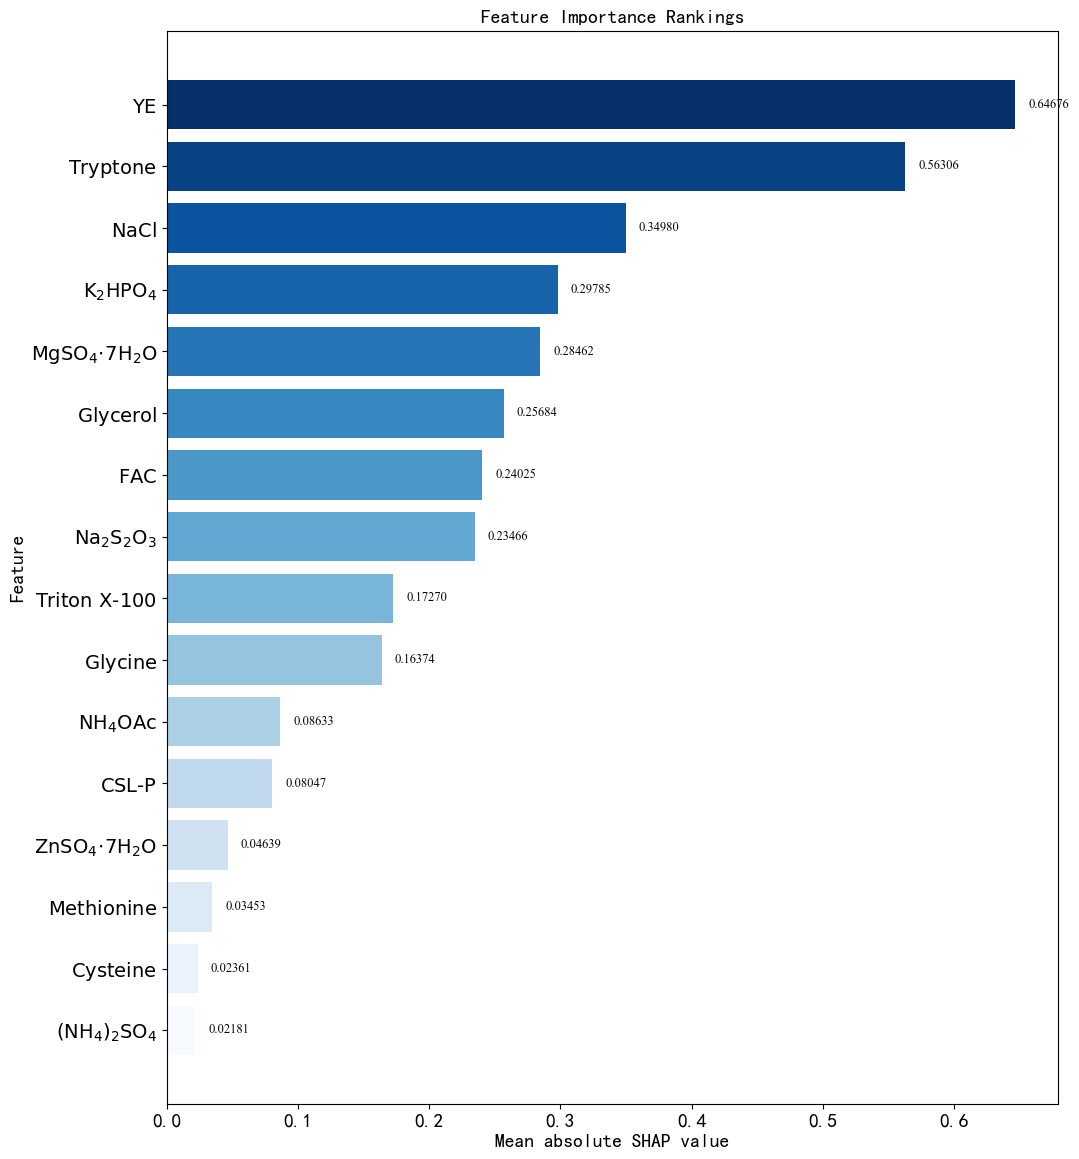

In [27]:
abs_shap_values = np.abs(shap_values)
mean_abs_shap_values = np.mean(abs_shap_values, axis=0)
sorted_indices = np.argsort(mean_abs_shap_values)[::-1]
# sorted_features = X_test.columns[sorted_indices]
sorted_mean_abs_shap_values = mean_abs_shap_values[sorted_indices]

# --- Adjustment: set the figure size to 8 cm x 12 cm ---
# Convert centimeters to inches (1 inch = 2.54 cm)
fig_width_cm = 28
fig_height_cm = 30
fig, ax = plt.subplots(figsize=(fig_width_cm / 2.54, fig_height_cm / 2.54))
# ----------------------------------------

# --- 1. Create a gradient from orange to light blue ---
from matplotlib.colors import LinearSegmentedColormap
# start_color = '#FFB6C1'  # Orange
# end_color = '#87ceeb'    # Light blue
n_colors = len(columns)
cmap = plt.cm.Blues_r
colors = cmap(np.linspace(0, 1, n_colors))
# ------------------------------------

# --- 2. Draw the bar chart ---
bars = ax.barh(range(len(columns)), sorted_mean_abs_shap_values, align='center', color=colors)
# -------------------

# --- 3. Refine fonts and formatting ---
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter

# Define fonts
font_text = FontProperties(family='SimHei', size=14)  # Chinese text: SimHei
font_num = FontProperties(family='Times New Roman', size=14) # Numbers: Times New Roman

# Set the title and axis labels
ax.set_title('Feature Importance Rankings', fontproperties=font_text, fontsize=14)
ax.set_xlabel('Mean absolute SHAP value', fontproperties=font_text, fontsize=14)
ax.set_ylabel('Feature', fontproperties=font_text, fontsize=14)

# Set Y-axis feature names (text)
ax.set_yticks(range(len(columns)))
ax.set_yticklabels(columns, fontproperties=font_text)

# Format numeric X-axis ticks to one decimal place
def format_x_axis(x, pos):
    return f'{x:.1f}'
ax.xaxis.set_major_formatter(FuncFormatter(format_x_axis))
# Apply Times New Roman to numeric ticks on both axes
ax.tick_params(axis='x', labelsize=12, labelrotation=0)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_text)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_text) # Y-axis tick labels are feature names; use SimHei

# Add value labels to the bars using Times New Roman for numbers
for i, v in enumerate(sorted_mean_abs_shap_values):
    ax.text(v + 0.01, i, f'{v:.5f}', va='center', fontproperties=font_num, fontsize=9)
# ------------------------------------

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(SHAP_MAIN_OUTPUT_DIR / 'mean_absolute_shap_values.png', bbox_inches='tight')
plt.show()


### 2.4 Single-Feature SHAP Dependence and LOESS Trends

For each feature, plot feature values against their SHAP values, overlay a LOESS smoothing curve and a zero reference line, and export a separate PDF.
Adjust the fixed Y-axis limits before running.

cross_idx: [150]


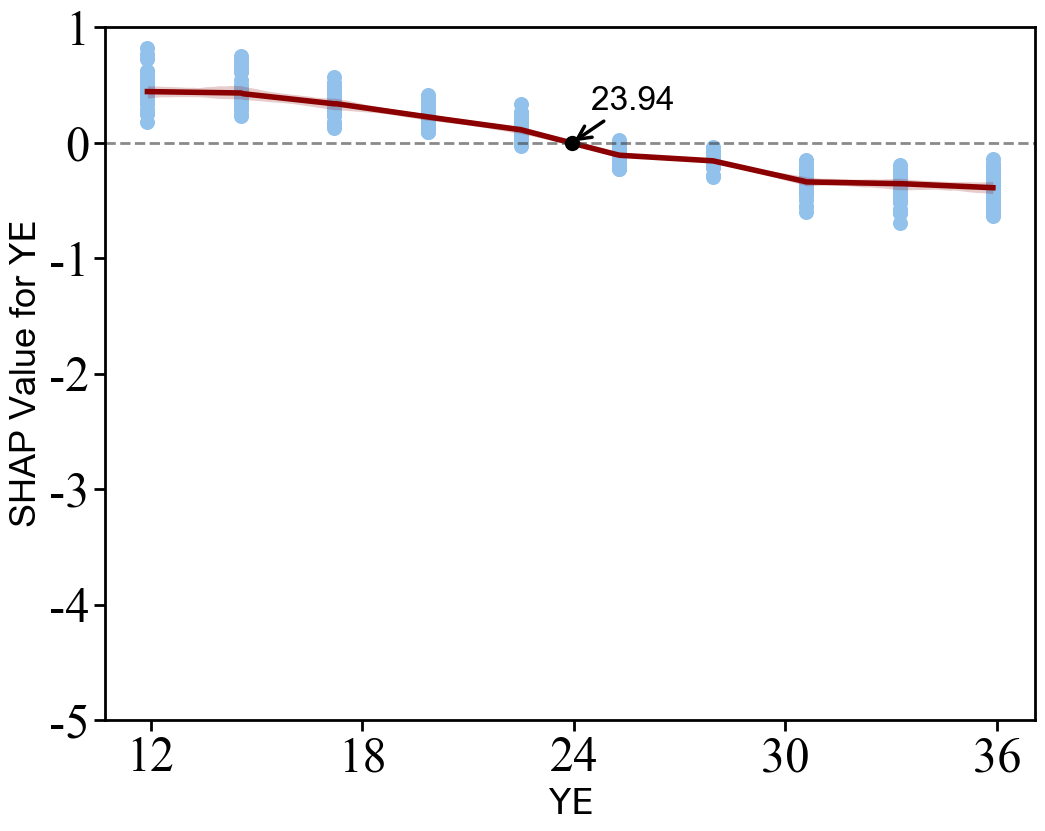

cross_idx: [161]


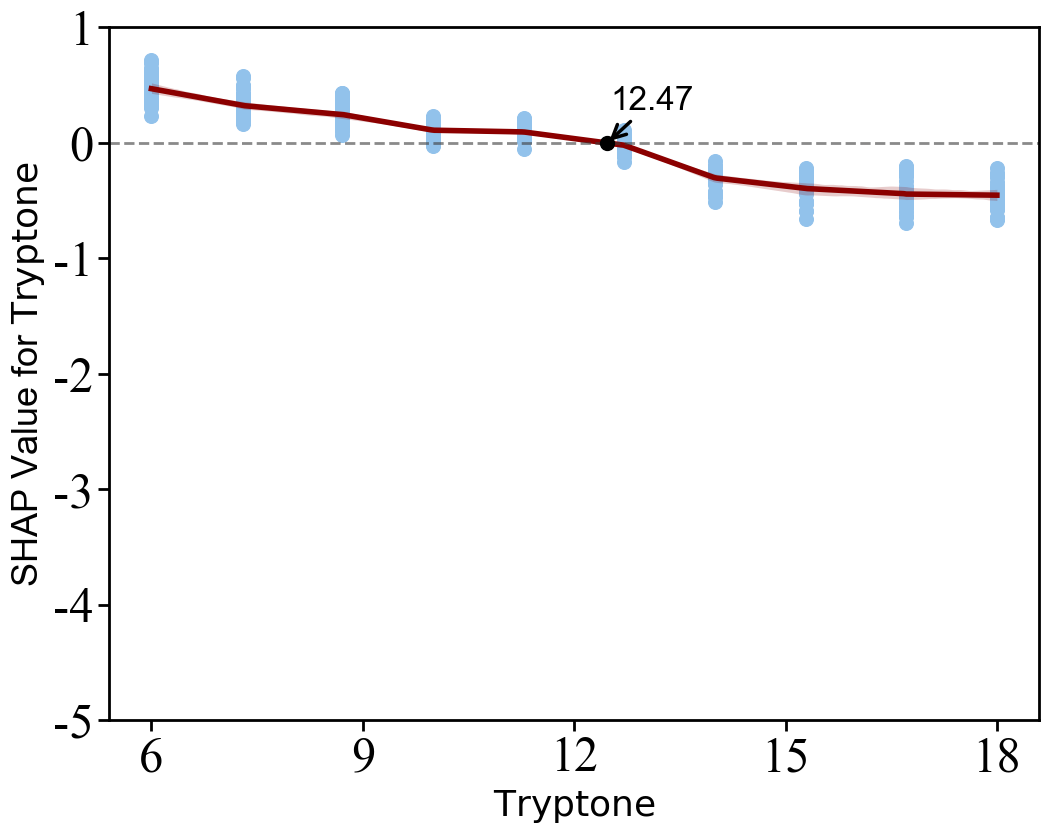

cross_idx: [ 33 125 157 175 243]


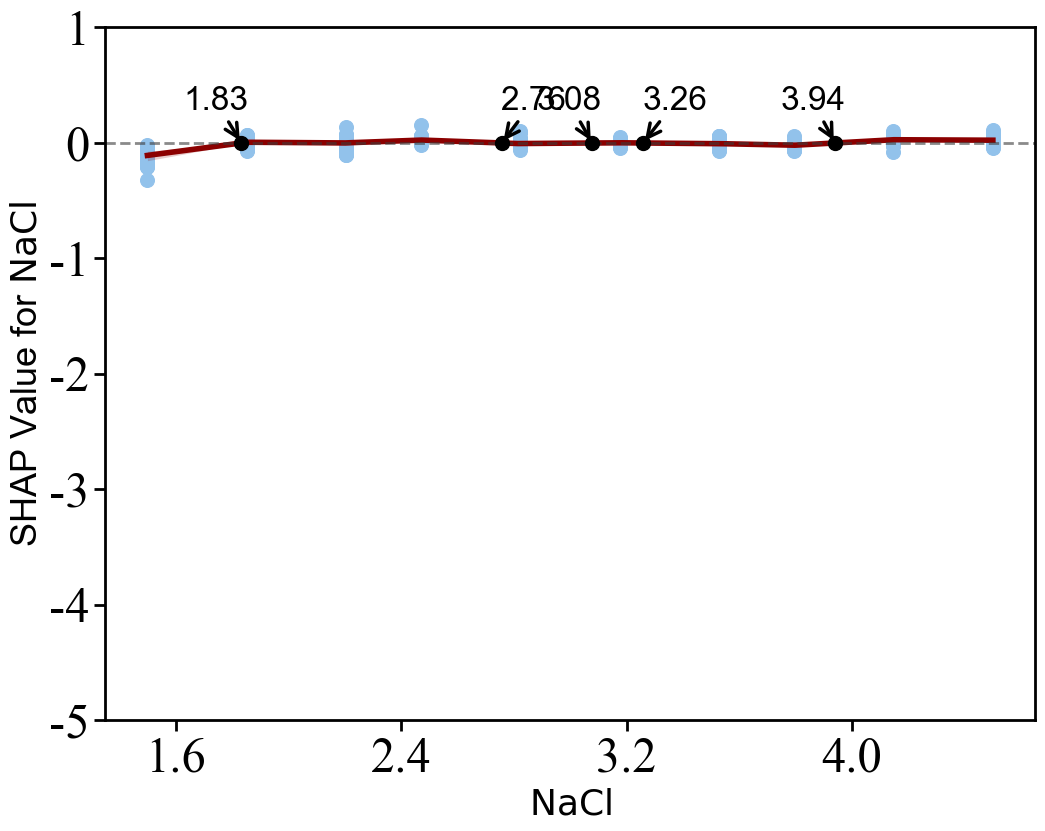

cross_idx: [207]


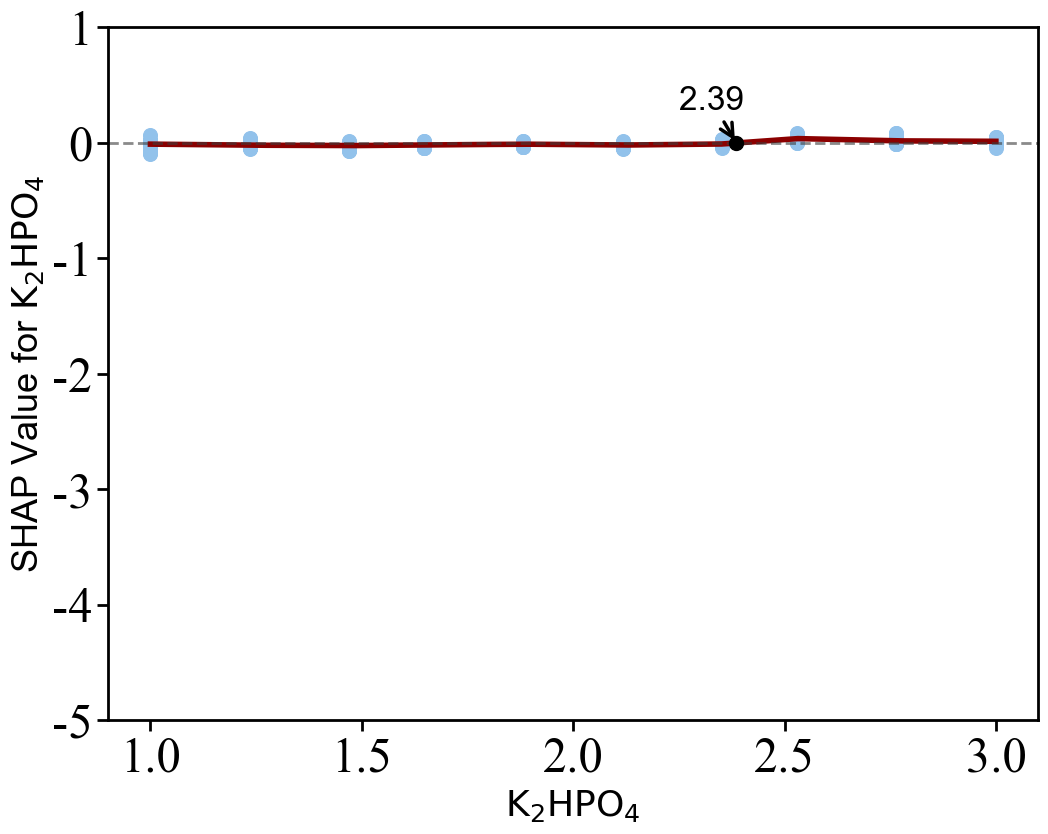

cross_idx: [158]


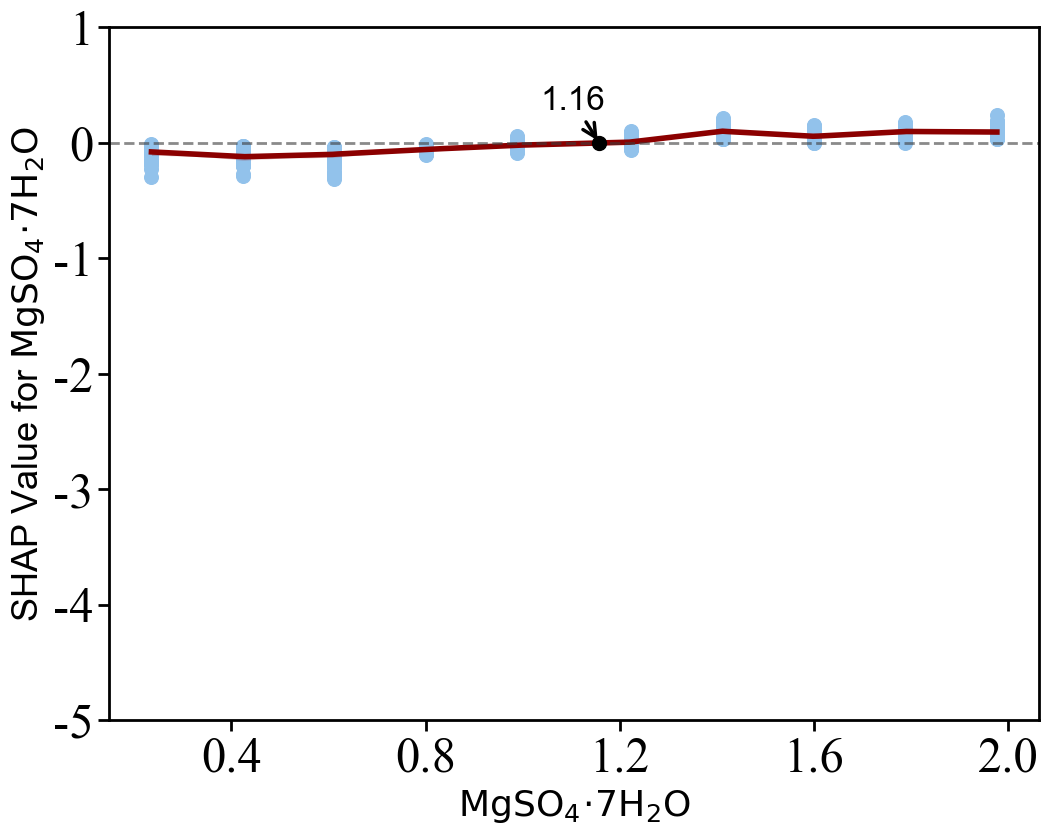

cross_idx: [135]


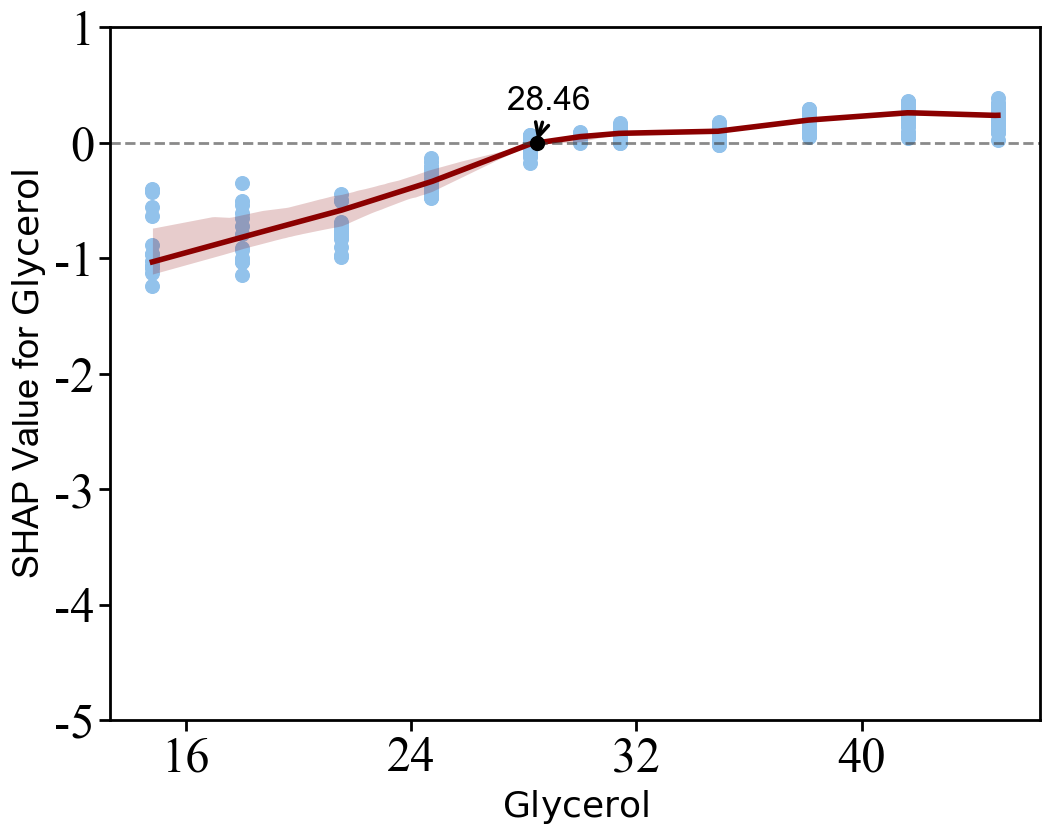

cross_idx: [147]


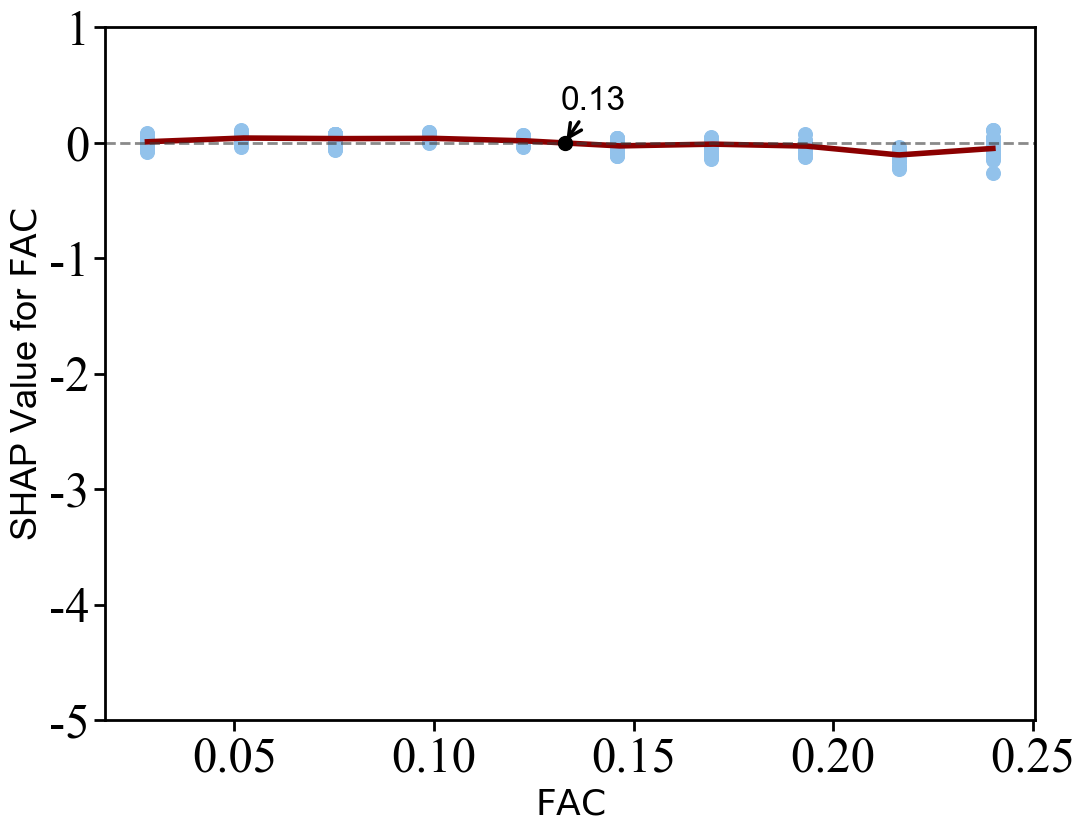

cross_idx: [115]


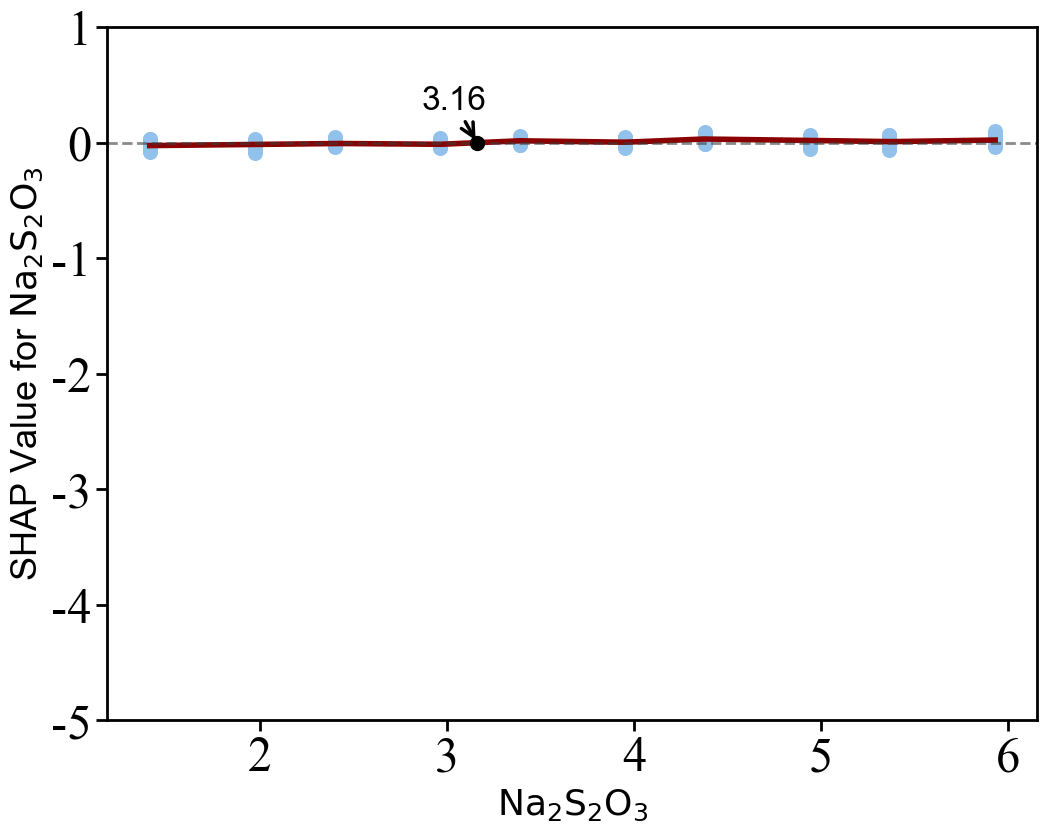

cross_idx: [93]


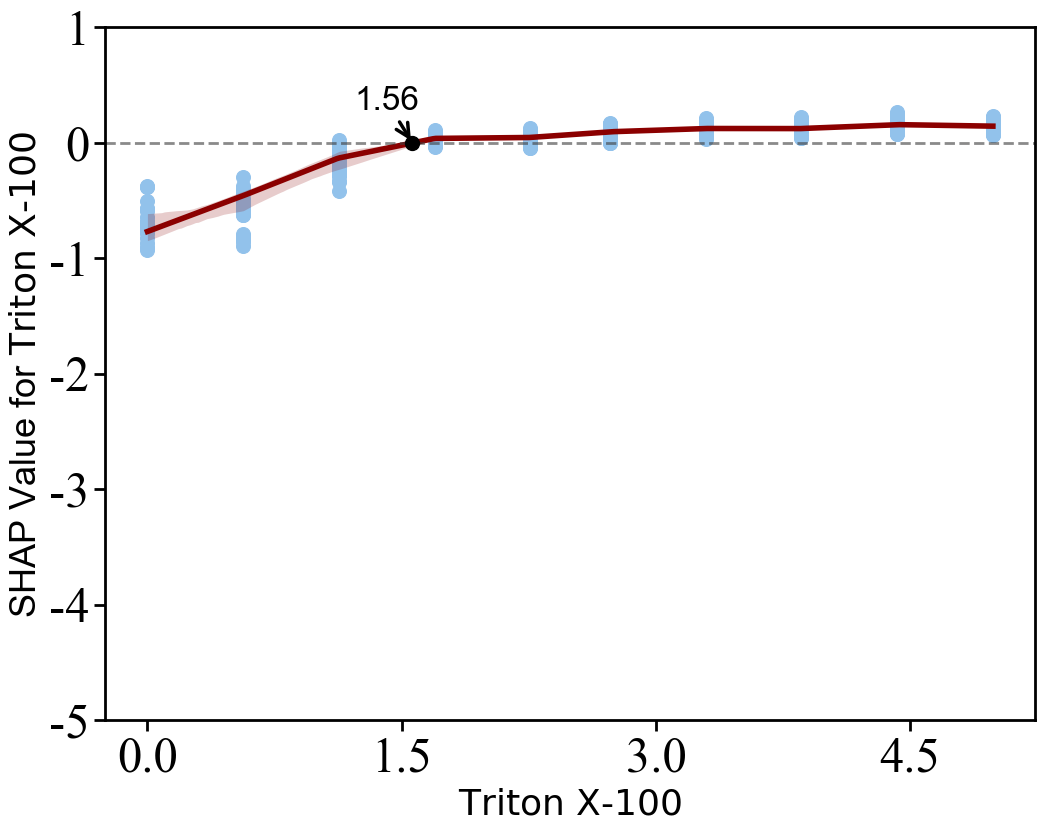

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [188]


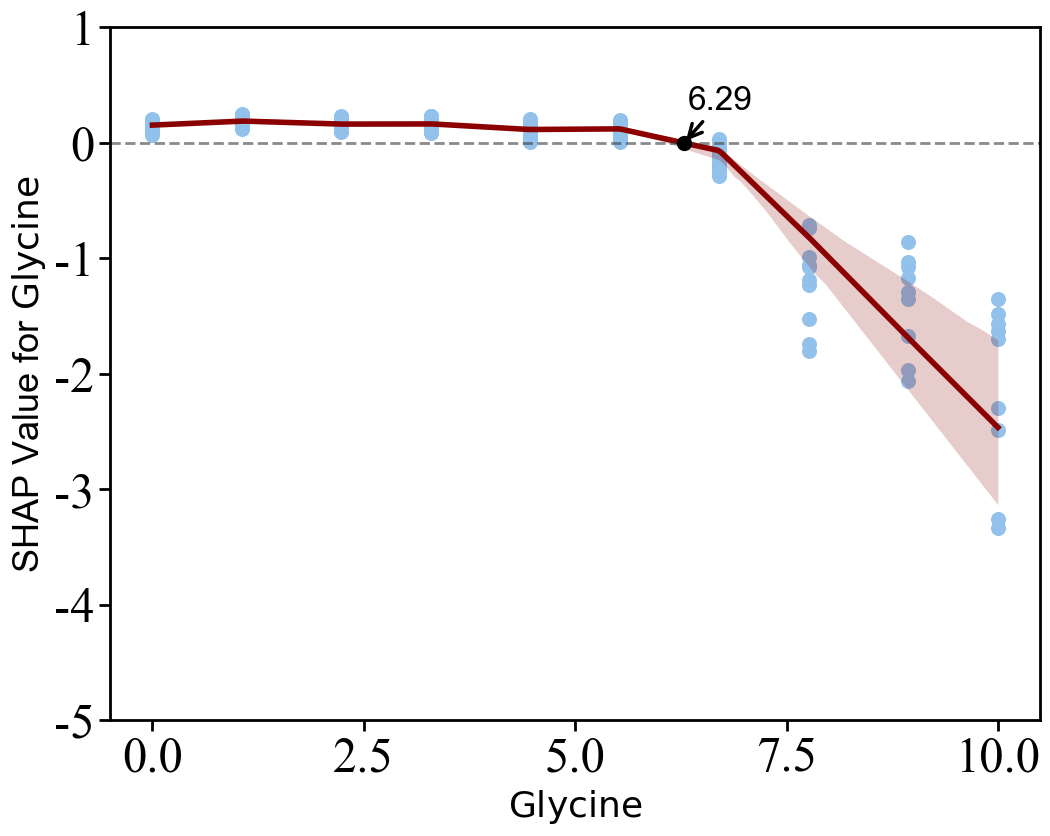

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [36]


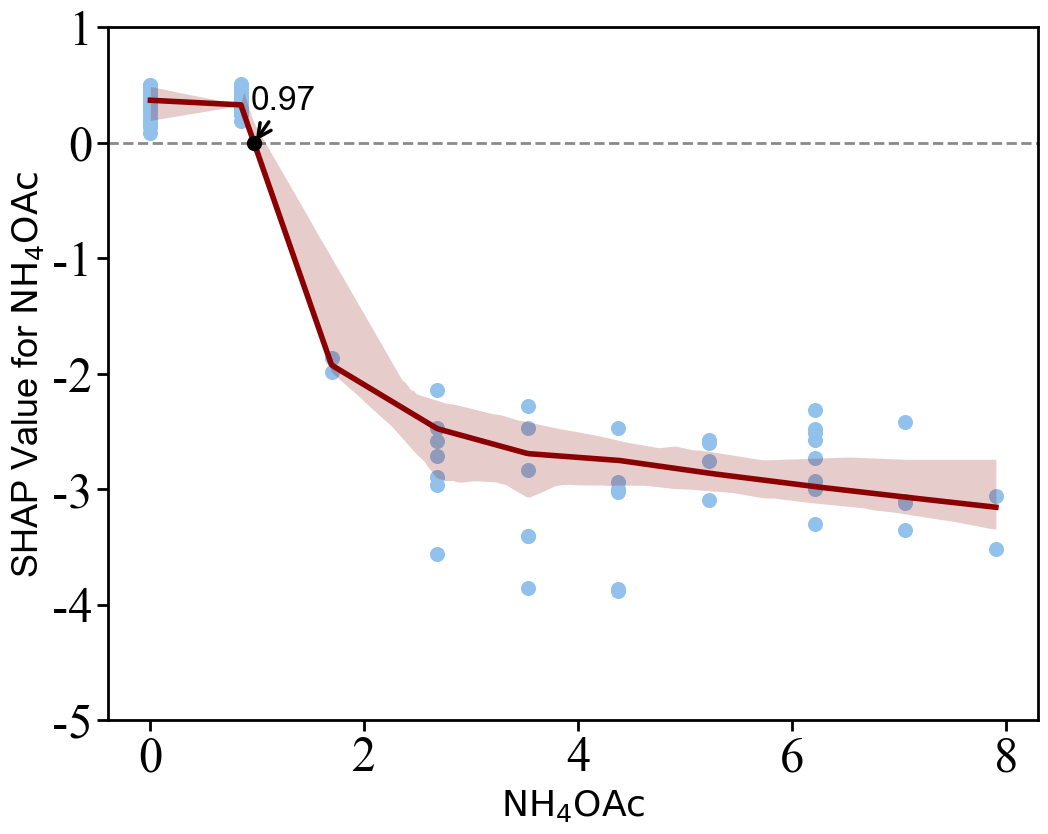

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [100]


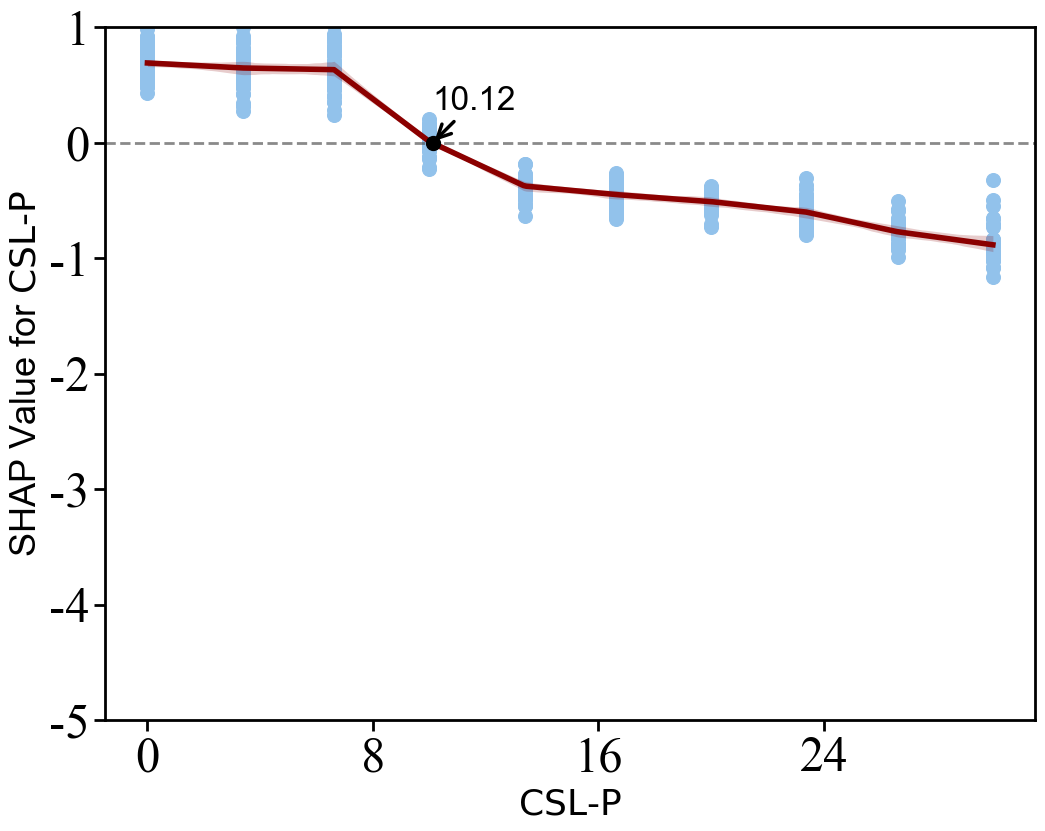

cross_idx: [129]


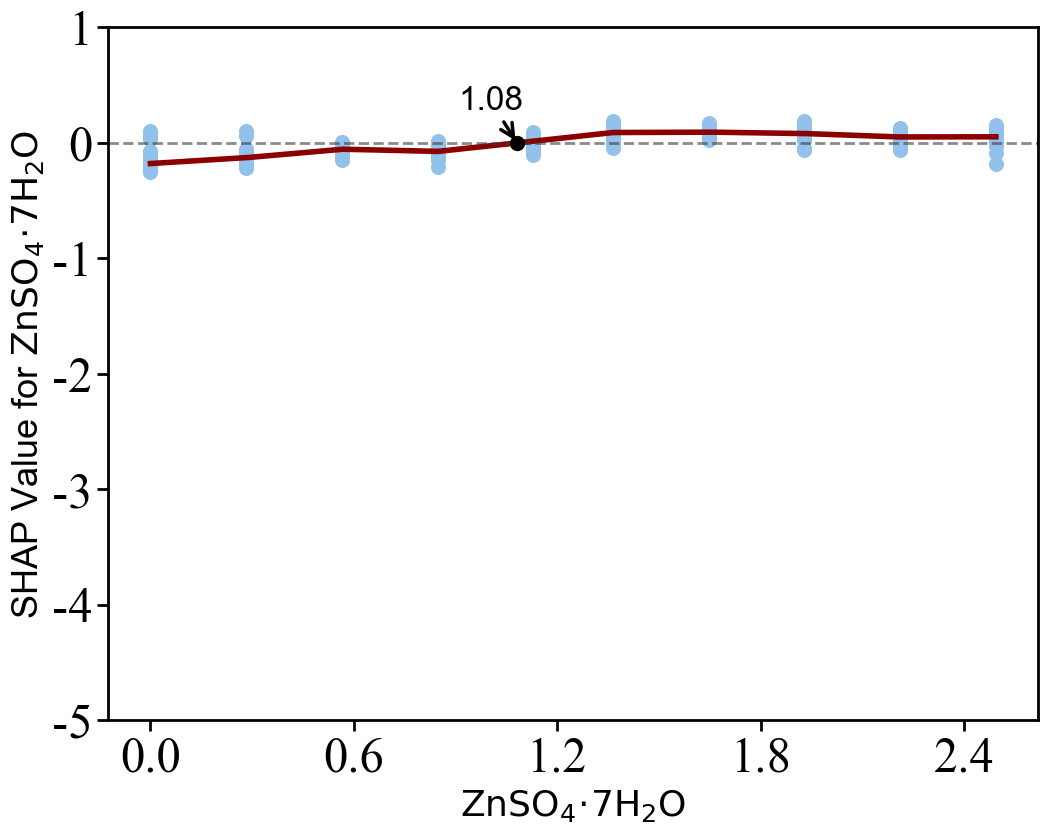

cross_idx: [224]


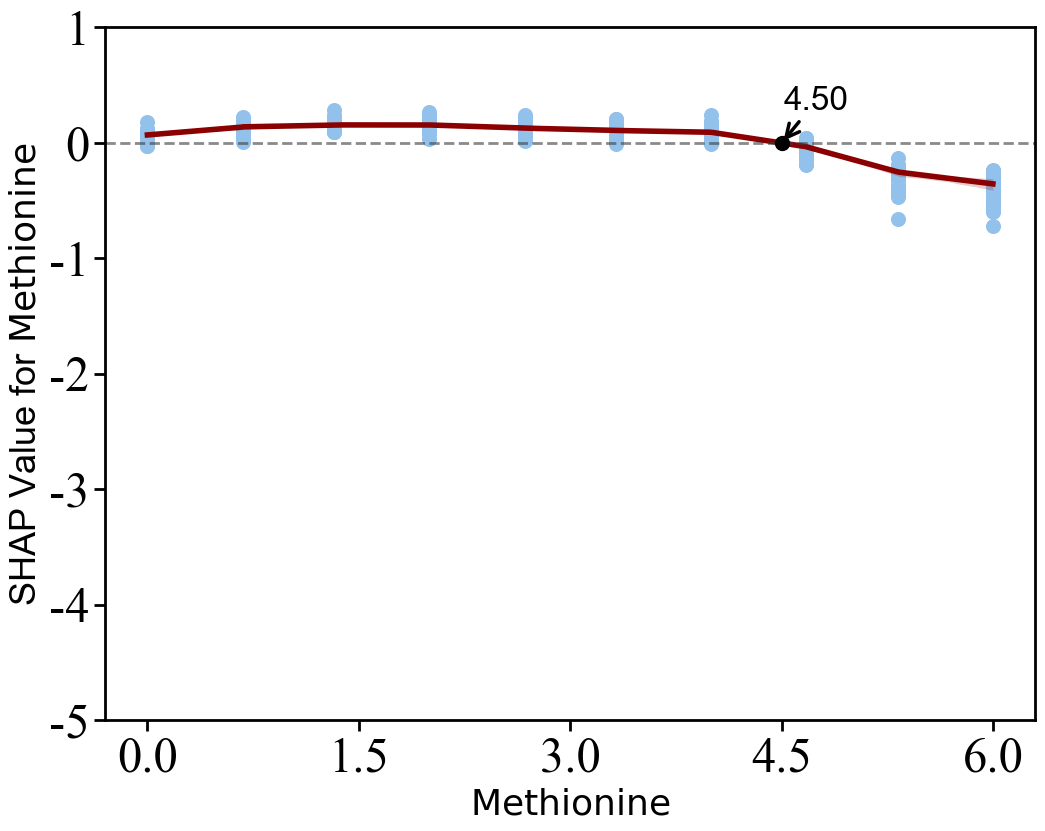

cross_idx: [138]


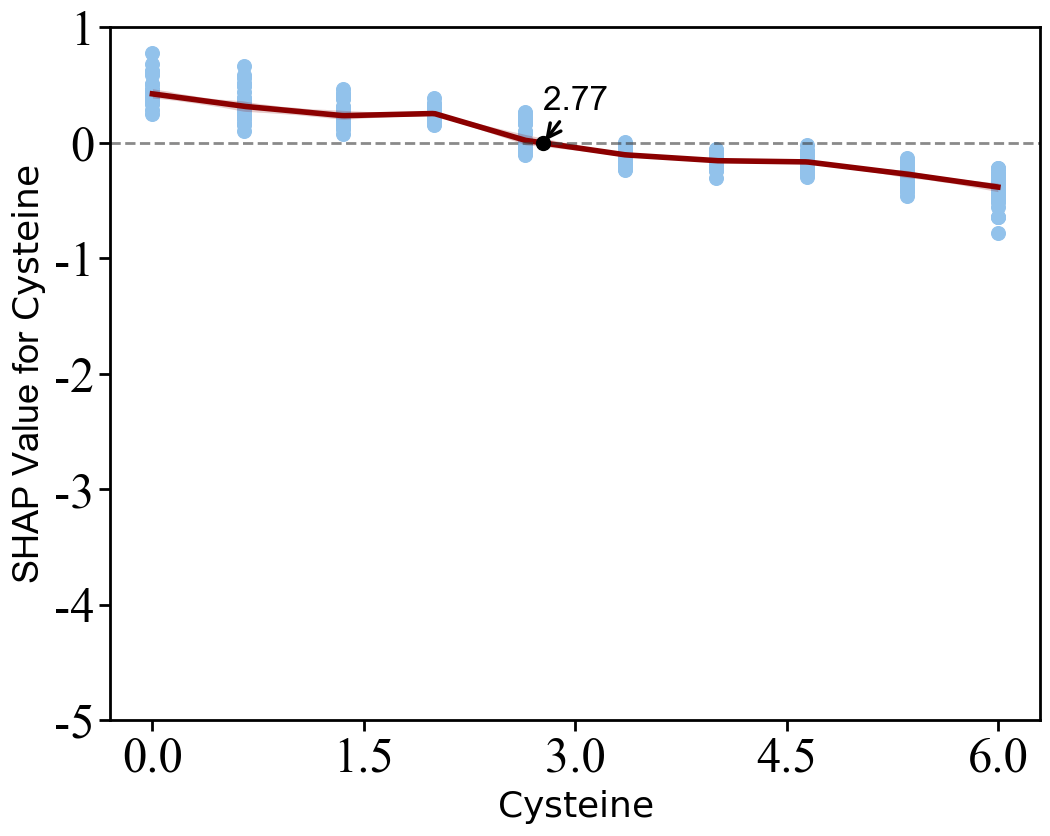

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [36]


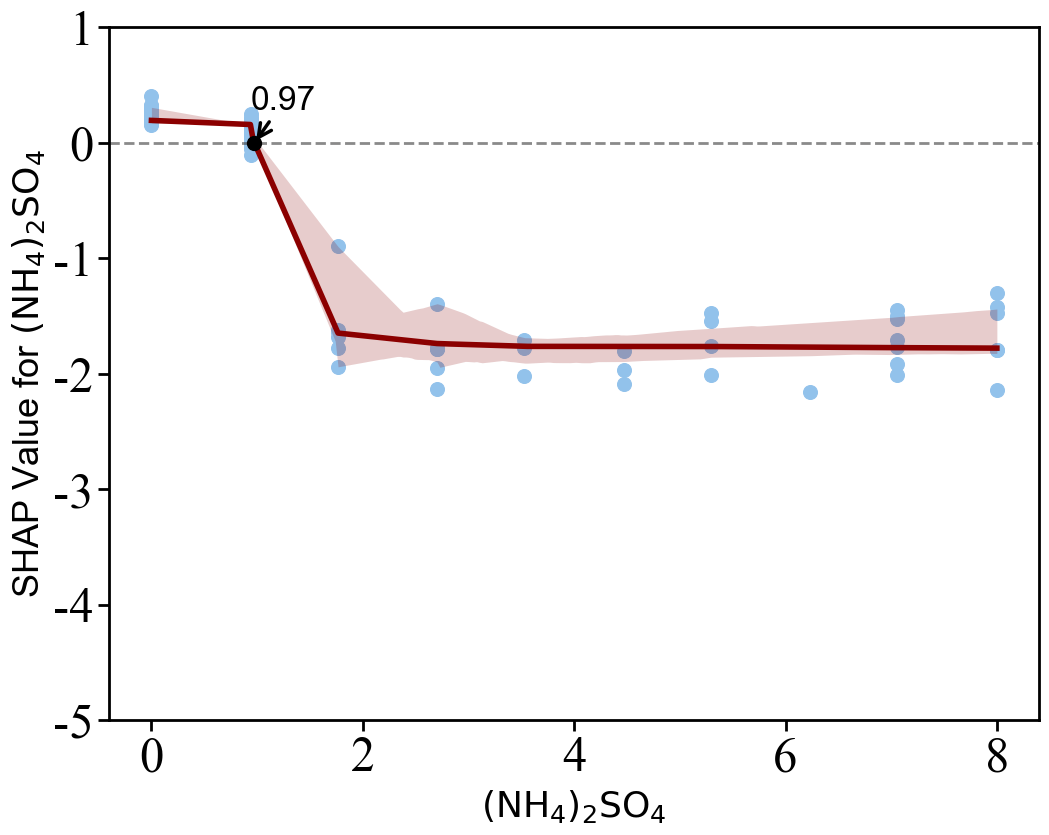

In [28]:
# SHAP main effect hyperparameter: LOWESS smoothing fraction for this dependence plot.
SHAP_DEPENDENCE_LOWESS_FRAC = 0.2

from matplotlib.font_manager import FontProperties

# LOESS Confidence Band and Axis Settings
LOESS_CONFIDENCE = 0.95       # Confidence level
LOESS_N_BOOTSTRAPS = 200      # Number of bootstrap iterations; larger values improve stability but take longer
SHAP_DEPENDENCE_YLIM = (-5, 1)   # Set the Y-axis limits here, for example:(-5, 1)(-200.0, 50.0)

rng = np.random.default_rng(RANDOM_SEED)

for i in range(X_train.shape[1]):  # Iterate over each feature
    plt.figure(figsize=(12, 9))
    
    # Ensure SHAP values are a NumPy array
    shap_array = shap_values[:, i]  # Get SHAP values for feature i
    
    # Draw the scatter plot
    sns.scatterplot(x=X.iloc[:, i], y=shap_array, 
                    color='#92C2EB', edgecolor='#92C2EB', s=100)  
    
    # Remove missing and infinite values before computing LOESS and confidence bands
    x_values = np.asarray(X.iloc[:, i], dtype=float)
    y_values = np.asarray(shap_array, dtype=float)
    valid_mask = np.isfinite(x_values) & np.isfinite(y_values)
    x_valid = x_values[valid_mask]
    y_valid = y_values[valid_mask]

    # LOESS curve
    # Fit the LOESS curve
    loess_result = lowess(y_valid, x_valid, frac=SHAP_DEPENDENCE_LOWESS_FRAC, return_sorted=True)
    x_grid = np.linspace(x_valid.min(), x_valid.max(), 300)
    loess_line = np.interp(x_grid, loess_result[:, 0], loess_result[:, 1])
    # Plot the LOESS curve
    plt.plot(x_grid, loess_line, color='#8B0000', linewidth=4, label='LOESS')


    # Set the confidence band method:'bootstrap' / 'layered_bootstrap' / 'none'
    confidence_mathod = 'bootstrap'
    if confidence_mathod != 'none':
        # Calculate confidence bands using bootstrap resampling
        if confidence_mathod == 'bootstrap':
            bootstrap_lines = []
            for _ in range(LOESS_N_BOOTSTRAPS):
                sample_idx = rng.integers(0, len(x_valid), len(x_valid))
                boot_result = lowess(
                    y_valid[sample_idx], x_valid[sample_idx],
                    frac=SHAP_DEPENDENCE_LOWESS_FRAC, return_sorted=True
                )
                bootstrap_lines.append(np.interp(x_grid, boot_result[:, 0], boot_result[:, 1]))

            alpha = (1 - LOESS_CONFIDENCE) / 2
            ci_lower, ci_upper = np.quantile(
                np.asarray(bootstrap_lines), [alpha, 1 - alpha], axis=0
            )

        # Calculate confidence bands using stratified bootstrap resampling
        if confidence_mathod == 'layered_bootstrap' :
            bootstrap_lines = []
            unique_x = np.unique(x_valid)
            for _ in range(LOESS_N_BOOTSTRAPS):
                boot_x = []
                boot_y = []
                for xv in unique_x:
                    # Find all samples at the current concentration level
                    mask = np.isclose(x_valid, xv)
                    x_group = x_valid[mask]
                    y_group = y_valid[mask]
                    # Sample with replacement within this concentration level
                    sample_idx = rng.integers(0,len(y_group),len(y_group))

                    boot_x.extend(x_group[sample_idx])
                    boot_y.extend(y_group[sample_idx])

                boot_x = np.asarray(boot_x)
                boot_y = np.asarray(boot_y)
                # Refit LOWESS to this bootstrap sample
                boot_result = lowess(boot_y,boot_x,frac=SHAP_DEPENDENCE_LOWESS_FRAC,return_sorted=True)

                # LOWESS may contain duplicate x values
                # Average fitted values for duplicate x values for subsequent interpolation
                boot_x_unique = np.unique(boot_result[:, 0])
                boot_y_unique = np.array([np.mean(boot_result[np.isclose(boot_result[:, 0], xv),1])
                    for xv in boot_x_unique])

                # Interpolate onto the shared x_grid
                boot_line = np.interp(x_grid,boot_x_unique,boot_y_unique)
                bootstrap_lines.append(boot_line)

            alpha = (1 - LOESS_CONFIDENCE) / 2
            ci_lower, ci_upper = np.quantile(
                np.asarray(bootstrap_lines),[alpha, 1 - alpha],axis=0
            )


        # Draw the confidence band
        plt.fill_between(x_grid, ci_lower, ci_upper, color='#8B0000', alpha=0.20,
                            linewidth=0, label=f'{LOESS_CONFIDENCE:.0%} CI')


    # Draw the zero reference line
    plt.axhline(y=0, color="#3D3C3C", linestyle='--', linewidth=2, alpha=0.6)


    # Plot intersections of the LOESS curve with y=0
    cross_idx = np.where(np.diff(np.sign(loess_line)) != 0)[0]
    print('cross_idx:', cross_idx)
    for idx in cross_idx:
        x1, x2 = x_grid[idx], x_grid[idx + 1]
        y1, y2 = loess_line[idx], loess_line[idx + 1]
        x_zero = x1 - y1 * (x2 - x1) / (y2 - y1)
        if y1-y2 >= 0 :
            xytext = (x_zero+20, 30)
        else:
            xytext = (x_zero-20, 30)
        plt.scatter(x_zero, 0, color='black', s=100, zorder=10)
        plt.annotate(f'{x_zero:.2f}', xy=(x_zero, 0), xytext=xytext,
                     textcoords='offset points', ha='center',va='center', fontsize=24,
                     arrowprops=dict(arrowstyle='->', color='black',linewidth=2.5,))   

    # Axis labels
    plt.xlabel(columns[i], fontsize=26, family='Arial')  
    plt.ylabel(f'SHAP Value for {columns[i]}', fontsize=26, family='Arial')  
    
    # Adjust tick parameters
    plt.tick_params(axis='both', which='both', labelsize=34, labelcolor='black', 
                    direction='out', length=8, width=2)


    # Set the number of X-axis ticks to 5
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    if SHAP_DEPENDENCE_YLIM is not None:
        ax.set_ylim(*SHAP_DEPENDENCE_YLIM)

    # Increase the font size of tick numbers
    font_properties = FontProperties(family='Times New Roman', size=35)
    for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        label.set_fontproperties(font_properties)

    # Darken and thicken the borders
    for spine in ax.spines.values():
        spine.set_edgecolor('black')  # Make the borders black
        spine.set_linewidth(2)  # Increase border thickness

    # Remove the default legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    plt.savefig(SHAP_MAIN_OUTPUT_DIR / f'shap_dependence_plot_{safe_filename(X.columns.values[i])}.svg', bbox_inches='tight')

    # Plot
    plt.show()

    


   

## 3. SHAP Interaction Effect Analysis

### 3.1 Calculate SHAP Interaction Values

Use the tree model explainer to compute the sample-level SHAP interaction value tensor for analyzing joint contributions of any pair of features.

In [29]:
shap_interaction_values = explainer.shap_interaction_values(X) 

### 3.2 SHAP Interaction Summary Plot

Plot a SHAP summary of interaction effects across all features and save it as a high-resolution PNG.

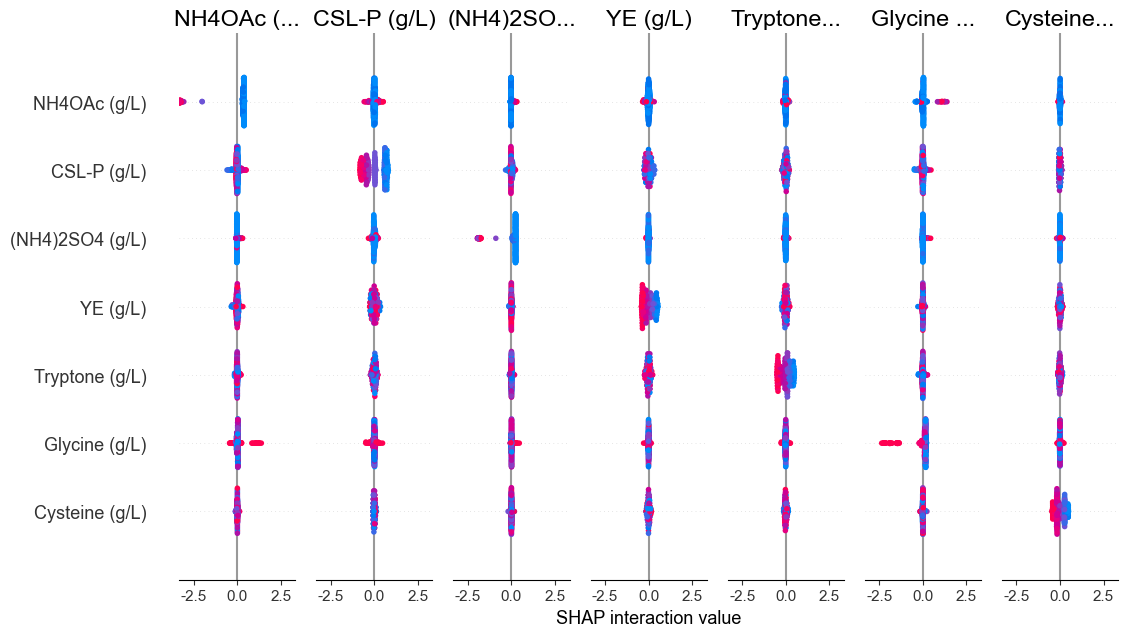

In [30]:
shap.summary_plot(shap_interaction_values, X, show=False)
plt.tight_layout()
plt.savefig(SHAP_INTERACTION_OUTPUT_DIR / 'shap_interaction_summary.png', dpi=300)
plt.show()

### 3.3 SHAP Interaction Matrix

Average absolute SHAP interaction values across samples for each feature pair, construct and visualize the interaction strength matrix, and use a shared color scale for comparison.

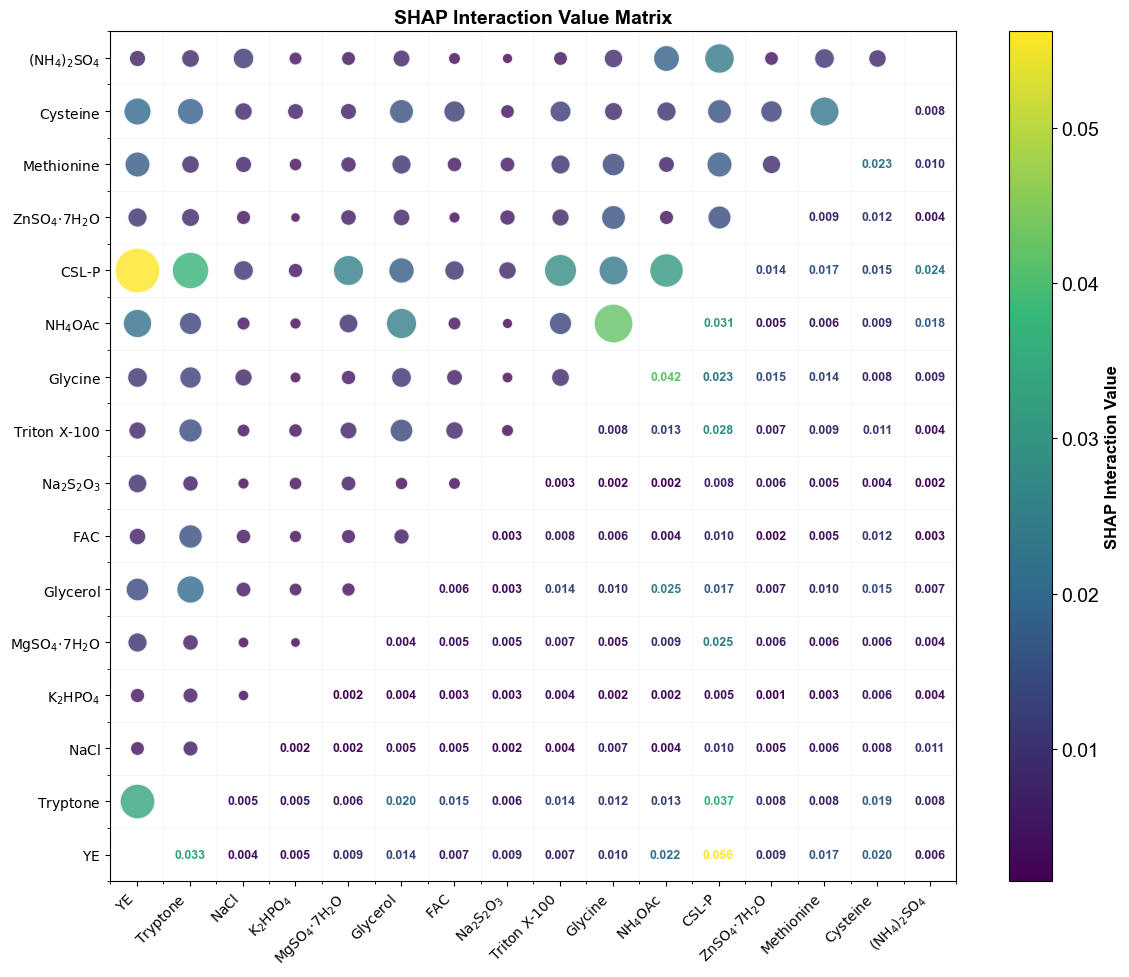

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize


feature_names = columns

# Calculate mean absolute SHAP interaction values
shap_interaction_mean = np.abs(shap_interaction_values).mean(0)

# Create the figure
fig, ax = plt.subplots(figsize=(12, 10))

# Create a colormap matching the original figure's color scheme
colors = ['#440154', '#31688e', '#35b779', '#fde725']
cmap = LinearSegmentedColormap.from_list('coolwarm', colors)

# Use shared normalization based on the range of the entire matrix, excluding the diagonal
off_diagonal_mask = ~np.eye(shap_interaction_mean.shape[0], dtype=bool)
off_diagonal_values = shap_interaction_mean[off_diagonal_mask]
vmin = off_diagonal_values.min()
vmax = off_diagonal_values.max()
norm = Normalize(vmin=vmin, vmax=vmax)

n_features = len(feature_names)

# Draw the heatmap content
for i in range(n_features):
    for j in range(n_features):
        value = shap_interaction_mean[i, j]
        
        if i < j:  # Upper triangle (above the main diagonal)
            # Display values with text colors mapped using the shared normalization
            color_intensity = norm(value)
            text_color = cmap(color_intensity)
            
            ax.text(j, i, f'{value:.3f}', 
                   ha='center', va='center', fontsize=9, 
                   color=text_color, fontweight='bold')
                   
        elif i > j:  # Lower triangle (below the main diagonal)
            # Display circles with sizes and colors mapped using the shared normalization
            # Calculate circle sizes using the shared normalization
            size_factor = norm(value)
            size = size_factor * 1000 + 50  # Adjust the size range
            
            # Draw circles using shared vmin and vmax
            ax.scatter(j, i, s=size, c=value, 
                      cmap=cmap, alpha=0.8, 
                      edgecolors='white', linewidth=1,
                      vmin=vmin, vmax=vmax)
        # Leave the main diagonal (i == j) blank

# Configure axes
ax.set_xlim(-0.5, n_features-0.5)
ax.set_ylim(-0.5, n_features-0.5)

# Set ticks and labels
ax.set_xticks(range(n_features))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(n_features))
ax.set_yticklabels(feature_names, fontsize=10)

# Add grid lines
ax.set_xticks(np.arange(-0.5, n_features, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_features, 1), minor=True)
ax.set_title('SHAP Interaction Value Matrix', fontsize=14, fontweight='bold')
ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=0.5, alpha=0.3)

# Add a colorbar using the shared normalization
scalar_mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
scalar_mappable.set_array(off_diagonal_values)
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=1, aspect=20)
cbar.set_label('SHAP Interaction Value', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.savefig(SHAP_INTERACTION_OUTPUT_DIR / 'shap_interaction_matrix.png', bbox_inches='tight')
plt.show()
